<h1>📚 Maestría en Inteligencia Artificial Aplicada – 3er Semestre</h1>

<h3>Asignatura: Procesamiento de Lenguaje Natural</h3>

<h4>Práctica Nro. 6 - Crea Tu propio ChatGPT usando RAG</h4>


<hr style="width:60%;">

<h2>👨‍🎓 Estudiantes</h2>
<ul style="list-style:none; padding:0; font-size:18px;">
    <li>Claudia Martínez</li>
    <li>Sebastián Murillas</li>
    <li>Mario J. Castellanos</li>
    <li>Enrique Manzano</li>
    <li>Octavio Guerra</li>
</ul>

<hr style="width:60%;">

<h3>📅 Fecha: Septiembre 28, 2025</h3>

</center>

# Retrieval-Augmented Generation (RAG) con Ollama y Langchain

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/semurillas/NLP_MIAA_252/blob/main/Sesion%206/Practice/2-ollama-langchain.ipynb)

Partiendo de los conceptos establecidos en el [1-ollama-rag.ipynb](./1-ollama-rag.ipynb) ahora exploraremos una implementación con herramientas más maduras que facilitan el manejo de RAGs y LLMs. Utilizaremos el mismo corpus de [Wikihow](https://es.wikihow.com/Portada). Además de eso, continuaremos el uso de [Ollama](https://ollama.com) y añadiremos el uso de [LangChain](https://www.langchain.com) un framework orientado al desarrollo de LLMs y agentes de IA. El objetivo final es el mismo, crear un RAG a partir de los documentos de wikihow. Observaremos que algunos de los pasos del notebook anterior se hacen de forma explicita.

**Nota:** En este notebook no se realizará el entrenamiento de ningún modelo, se utilizarán modelos pre-entrenados y se combinaran de una forma interesante para hacer uso de cada componente a su modo y crear un agente de conversación


### References
- [Newtral Simple RAG Example](https://github.com/LozanoAlvarezb/MLOPS-Newtral)
- [Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks](http://arxiv.org/abs/2005.11401)
- [Natural Language Processing with Transformers: Building Language Applications With Hugging Face](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246)
- [Hugging Face Transformers](https://huggingface.co/docs/transformers/v4.41.3/en/index)

## **1. Chequeo de ambiente y Manejo de "Warnings"**

Iniciamos verificando si estamos trabajando en "Google Colab" y deshabilitar algun mensaje de "warning" durante la ejecución de las celdas de código Python.

In [2]:
import importlib.metadata    # Importación del modulo de metadata de la libreria importlib
import warnings               # Importación de la libreria warnings

# Uso de la libreria importlib.metadata para obtener los paquetes
# instalados en el Notebook
installed_packages = [dist.metadata['Name'].lower() for dist in importlib.metadata.Distribution.discover()]

# Chequeando que Google Colab este entre los paquetes instalados
# para confirmar si es el ambiente de trabajo usado.
IN_COLAB = 'google-colab' in installed_packages

# Ignorar algun Warning generado durante la ejecución del Notebook
warnings.filterwarnings('ignore')

## **2. Preparación del Entorno de Google Colab para la práctica**

En esta sección, preparamos y dejamos listo el ambiente de Google Colab para nuestro RAG y la práctica de crear nuestro propio ChatGPT. Instalaremos todas las librerías requiridas y nos aseguraremos de que el sistema operativo esté al día.

1. Instalación de las librerías usando el archivo requirementes.txt. Este archivo nos da todas las piezas para el RAG:

- RAG Core (faiss-cpu, sentence-transformers): El motor de búsqueda (FAISS) y el modelo de embeddings (E5-Large).

- Conectores LangChain (langchain-ollama, langchain-community, langchain-huggingface): Las APIs que nos dejan unirr todo: los embeddings, el índice FAISS y el LLM de Ollama.

- Servicio Local (ollama, colab-xterm): Para correr el LLM en la GPU de Colab. colab-xterm nos da la terminal para iniciar el servicio de LLM en segundo plano.

- UI (gradio): Para correr la interfaz del chat y asi poder probarlo.

2. Actualización y Dependencias
El código primero usa sudo apt-get update para actualizar la lista de paquetes que es la base de Colab. Esto evita errores con versiones viejas de librerías.

 El uso de !test '{IN_COLAB}' = 'True' es una validación rápida que asegura que las instalaciones solo se corran si estamos en Colab. Si alguien usa el notebook localmente, no son instaladas ninguna de las librerías mencionadas en el archivo requirements.txt


In [3]:
!test '{IN_COLAB}' = 'True' && pip install -r "https://raw.githubusercontent.com/semurillas/NLP_MIAA_252/refs/heads/main/Sesion%206/Practice/requirements.txt?nocache=$(date +%s)"
!test '{IN_COLAB}' = 'True' && sudo apt-get update -y

INFO: pip is looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.7 MB/s eta 0:00:00
Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,014 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:7 http://archive.ubuntu.com/ubuntu jam

## **3. Importación de Librerías**

A continuación realizamos la importación de las librerías requeridas para el desarrollo completo de la practica:

- **Manejo de datos y visualización** (`pandas`, `matplotlib`, `faiss`).  
- **Hugging Face y embeddings** (`datasets`, `HuggingFaceEmbeddings`).  
- **LangChain** (componentes core, RAG y conectores como FAISS y ChatOllama). Requeridos para definir un LLM y la base de datos vectorizada de documentos de un Dataset previamente seleccionado.
- **Interfaz** con `gradio` para probar por medio de Chatbot el modelo RAG creado en el proceso.

In [55]:
# ==================================
# 1. UTILIDADES Y MANEJO DE DATOS
# ==================================

# Importamos os para trabajar con variables de entorno y rutas del sistema operativo
import os
# Importamos pandas para manipular y analizar datos en forma de tablas (DataFrames)
import pandas as pd
# Importamos matplotlib para poder graficar y visualizar datos
import matplotlib.pyplot as plt
# Importamos faiss para hacer búsquedas vectoriales rápidas
import faiss
# Importamos random (aunque en este caso no lo usamos, es útil para pruebas aleatorias)
import random


# ==================================
# 2. HUGGING FACE Y DATASETS
# ==================================

# Importamos la librería datasets para cargar conjuntos de datos listos para usar
from datasets import load_dataset
# Importamos HuggingFaceEmbeddings para generar representaciones vectoriales de texto (embeddings)
from langchain_huggingface import HuggingFaceEmbeddings


# ==================================
# 3. LANGCHAIN CORE (Componentes Fundamentales)
# ==================================

# Componentes base que definen los tipos de datos y mensajes
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain.schema import HumanMessage, AIMessage # Tipos de mensajes para historial/chat


# ==================================
# 4. LANGCHAIN COMMUNITY (Integraciones)
# ==================================

# Importamos FAISS de la comunidad de LangChain para guardar y consultar embeddings
from langchain_community.vectorstores import FAISS
# Importamos ChatOllama para conectarnos con modelos de lenguaje que corren con Ollama
from langchain_ollama import ChatOllama


# ==================================
# 5. LANGCHAIN CHAINS Y UTILERÍAS RAG
# ==================================

# Importamos PromptTemplate para diseñar plantillas de prompts
from langchain.prompts import PromptTemplate
# Importamos create_stuff_documents_chain para combinar documentos y prompts (paso de generación)
from langchain.chains.combine_documents import create_stuff_documents_chain
# Importamos create_retrieval_chain para unir el retriever y la generación (paso final RAG)
from langchain.chains import create_retrieval_chain
# Importamos RetrievalQA (cadena antigua/simple para QA con RAG)
from langchain.chains import RetrievalQA
# Cadenas para historial conversacional (aunque no lo uses aún, ya está importado)
from langchain.chains import create_history_aware_retriever


# ==================================
# 6. INTERFAZ GRÁFICA (FRONT-END)
# ==================================

# Importamos la librería Gradio para crear interfaces gráficas sencillas en la web
import gradio as gr

## **3. Selección de Dataset para la Práctica**

Como equipo trabajando en el desarrollo de esta práctica hemos seleccionado  Dataset MessIRve ([https://arxiv.org/abs/2409.05994](https://arxiv.org/abs/2409.05994)) por tres razones para montar nuestro RAG (el motor de nuestro chat):

1. Es un Dataset grande y en idioma Español (≈730K): Es una base de conocimiento gigante y en el idioma español. Siempre es bueno contar con un buen volumen de datos (≈730,000 registros) para que la Recuperación (Retrieval) no nos falle al recibir preguntas.

2. Hecho para Recuperación: No son solo textos sueltos. Son pares de "Consulta real de Google" vs. "Documento de Wikipedia relevante". Esto es la mejor data para entrenar y testear los embeddings que usa nuestro RAG.

3. Enfocado en lo Real: Las consultas de Google son preguntas de gente real, no inventadas. Al final, esa es la input que recibirá nuestro "ChatGPT", así que, creemos que es perfecto para hacer tuning y pruebas.

Creemos que este dataset  MessIRve nos da el volumen y la calidad de datos directamente aplicables a la lógica de consulta-respuesta de la práctica que realizaremos en este Google Colab Notebook.

In [5]:
# Carga el dataset MessIRve (configuración 'co') de Hugging Face.
# Solo traemos el split 'train', que es nuestro corpus para el RAG.
dataset = load_dataset('spanish-ir/messirve', 'co', split='train')

# Imprime el objeto 'Dataset' para verificar la estructura (columnas) y el tamaño.
dataset

README.md: 0.00B [00:00, ?B/s]

co/train-00000-of-00001.parquet:   0%|          | 0.00/6.66M [00:00<?, ?B/s]

co/test-00000-of-00001.parquet:   0%|          | 0.00/1.64M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25914 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5667 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'query', 'docid', 'docid_text', 'query_date', 'answer_date', 'match_score', 'expanded_search', 'answer_type'],
    num_rows: 25914
})

### **3.1. Muestra del Dataset seleccionado en formato Panda Dataframe**

Veamos el Dataset que hemos seleccionado pero usando Panda Dataframes. Es al final una manera mas "estética" de verlo.

In [6]:
# Establecemos para el formato Panda un ancho de 100 caracteres
# para que no nos trunque los textos al mostrarlos.
# y asi podamos inspeccionar mejor las consultas y documentos completos del MessIRve.
pd.set_option('display.max_colwidth', 100)

# Aplicamos el formato 'pandas' al objeto Dataset de Hugging Face.
# De nuevo es una manera mas "estética" de verlo
dataset.set_format(type='pandas')

# Convertimos el dataset usado a un DataFrame de Pandas estándar.
df = dataset.to_pandas()

# Mostramos las primeras 15 filas del DataFrame (df)
df.head(15)

,id,query,docid,docid_text,query_date,answer_date,match_score,expanded_search,answer_type
0,840860,a cual continente pertenece republica dominicana,8005#1,"La República Dominicana es un país de América situado en el Caribe, ubicado en la zona central d...",2024-03-30,2024-04-19,1.0,False,feat_snip
1,840861,a cual corea no se puede entrar,4430#18,"Corea del Norte es uno de los sitios más aislados del mundo, con severas restricciones en la ent...",2024-03-30,2024-04-25,1.0,False,feat_snip
2,840864,a cual de estas areas afecto la 1 revolucion industrial,630511#4,"La Primera Revolución Industrial se caracterizó por el nacimiento de la industria textil, la máq...",2024-03-30,2024-04-19,1.0,False,feat_snip
3,840866,a cual de las regiones estudiadas pertenece republica dominicana,8005#1,"La República Dominicana es un país de América situado en el Caribe, ubicado en la zona central d...",2024-03-30,2024-04-19,1.0,False,feat_snip
4,840885,a cual epoca se le llamo medioevo,1140#1,La Edad Media o el Medievo es el período histórico de la civilización occidental comprendido ent...,2024-04-03,2024-04-25,1.0,True,feat_snip
5,840896,a cual o a quien,3328953#1,"Wikipedia es una enciclopedia libre, políglota y editada de manera colaborativa. Es administrada...",2024-03-30,2024-04-25,1.0,False,descript
6,840898,a cual santo se le pide trabajo,746331#1,"Cayetano de Thiene, en italiano Gaetano (Vicenza, 1 de octubre de 1480 - Nápoles, 7 de agosto de...",2024-04-03,2024-04-19,1.0,False,feat_snip
7,840921,a cuales países emigran los dominicanos,8005#46,"Todos los niveles de la educación se desplomaron, la universidad fue cerrada, ya que los hombres...",2024-03-30,2024-04-19,1.0,False,feat_snip
8,840930,a cuales son los reinos de la naturaleza,26856#8,"En 1860 el biólogo inglés John Hogg, postula el tercer ""Regnium primigenium"" o ""Protoctista"" par...",2024-03-30,2024-04-26,1.0,False,feat_snip
9,840931,a cuales son los textos narrativos,405925#21,El texto narrativo es el relato de acontecimientos desarrollados en un tiempo o lugar determinad...,2024-03-30,2024-04-19,1.0,False,feat_snip


### **3.2. Gráfica de distribución de Cantidad de Palabras en los Documentos del Dataset**

En la Gráfica a continuación visualizamos cómo se distribuye la cantidad de palabras en los documentos del dataset.  
Cada barra del histograma representa la frecuencia de documentos que tienen un cierto número de palabras, permitiéndonos identificar los tamaños más comunes de los textos.

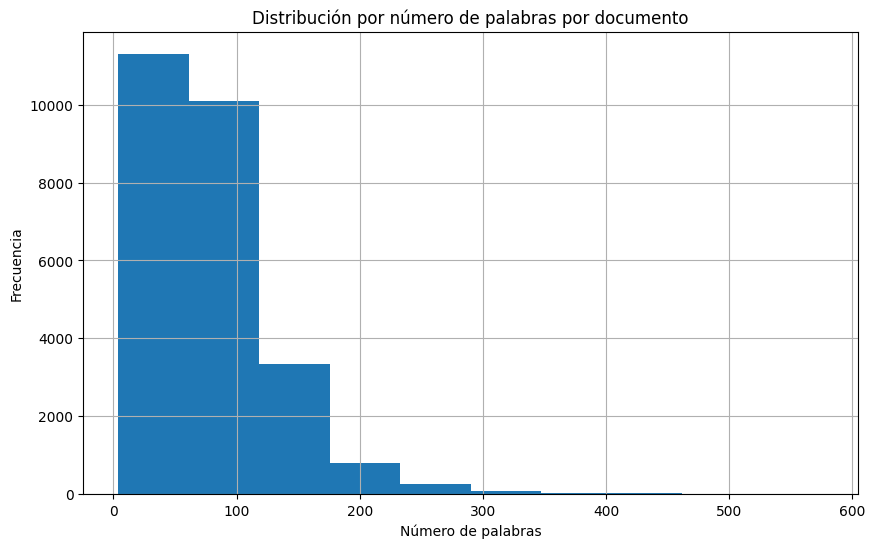

In [7]:

# Creamos la figura y el eje para el gráfico, definiendo el tamaño de la figura
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Contamos la cantidad de palabras en cada documento y generamos un histograma
df.docid_text.apply(lambda text: len(text.split(' '))).hist(ax=ax)

# Colocamos un título del gráfico para identificarlo y saber de que se trata
ax.set_title("Distribución por número de palabras por documento")

# Etiquetamos el eje X (número de palabras)
ax.set_xlabel("Número de palabras")

# Etiquetamos el eje Y (frecuencia de documentos con esa cantidad de palabras)
ax.set_ylabel("Frecuencia")

# Finalmente, mostramos el gráfico en pantalla
plt.show()


### **Comentario sobre Distribución de Palabras por documento del Dataset**

La gráfica muestra que la mayoría de los documentos del dataset tienen entre 1 a 100 palabras, lo que indica que los textos son en su mayoría cortos. Entre 110 y 180 palabras, el número de documentos disminuye notablemente a menos de 4,000, y a partir de 230 palabras en adelante, los documentos son mucho menos frecuentes, con menos de 1,000 ocurrencias por rango. Esta distribución sugiere que el dataset está compuesto principalmente por documentos breves, con pocos textos extensos.

## **4. Proceso de Creación de nuestro propio ChatGPT usando RAG**

En este notebook usarémos LangChain y FAISS para crear el document store. Por ahora vamos a saltarnos el paso de chunking ya que esta combinación de librerías realiza lo suficientemente bien la tarea con los documentos enteros. Sin embargo, en entornos reales, el chunking podría seguir siendo necesario.

### **4.1. Instalando a Ollama**

En la siguiente línea de código instalamos Ollama, que es la herramienta que nos permite ejecutar modelos de lenguaje grandes (LLMs) directamente en el ambiente de Google Colab (aprovechando la GPU si está disponible). Este paso es muy importante porque sin Ollama, no podemos tener el LLM que va a interactuar con nuestra base de datos vectorial (el RAG).


In [8]:
!if ! type ollama > /dev/null; then curl -fsSL https://ollama.com/install.sh | sh; else echo "Ollama ya está instalado."; fi

/bin/bash: line 1: type: ollama: not found
>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


### **4.2. Iniciando Ollama en Segundo Plano (Background) en el Notebook**

La línea de código a ocntinuacion,  es el que nos permite ejecutar Ollama, el servidor que va a alojar y correr nuestro modelo de lenguaje (LLM). Debemos verlo como el "servidor web local" que ejecuta el cerebro de nuestro chatbot. De esta manera, ya podemos cargar el LLM y conectarlo a nuestra base de datos vectorial

In [10]:
!nohup ollama serve > ollama.log 2>&1 &

### **4.3. Cargue del Modelo llama3.2:3b**

Con la siguiente línea de código, estamos cargando el modelo lingüístico (llama3.2:3b) en el servidor que acabamos de encender (ollama serve). Una vez que la descarga termine, tendremos el LLM listo para hablar y, en la siguiente fase, lo conectaremos a nuestra base de datos vectorial (FAISS) para crear el Chatbot RAG completo.

In [11]:
!ollama pull llama3.2:3b

### **4.4. Creando un objeto LLM y probándolo**

En la siguiente línea de código, creamos el objeto llm, que ahora representa a Llama 3.2 dentro de LangChain. Este objeto está listo para recibir el contexto de nuestra base de datos vectorial (FAISS) y generar respuestas inteligentes a preguntas que hagamos.

LangChain tiene capacidades para interactuar con múltiples LLMs, sobretodo los de nivel enterprise (OpenAI, Mistral, Gemini, Claude, etc.,). Para mantener las cosas simples, continuaremos con un modelo llama a través de Ollama.


In [12]:

llm = ChatOllama(model="llama3.2:3b", validate_model_on_init=True)

llm.invoke("Quien es Michael Jackson...").content

'Michael Joseph Jackson (Augusto 29, 1958 - June 25, 2009) fue un cantante, compositor y bailarín estadounidense. Considerado por muchos como uno de los músicos más influyentes y exitosos de todos los tiempos.\n\n**Infancia y carrera**\n\nMichael Jackson nació en Gary, Indiana, y comenzó su carrera musical a una edad temprana, tocando el teclado y cantando con su familia. En 1969, se unió al grupo de R&B The Jackson 5, que se convirtió en una de las bandas más populares de la época.\n\n**Éxito como solista**\n\nEn 1971, Michael Jackson dejó el grupo para lanzar su carrera en solitario. Su primer álbum, "Got to Be There", fue un éxito moderado, pero fue su segundo álbum, "Ben", que lanzó en 1972, el que lo catapultó a la fama. Sin embargo, fue su tercero álbum, "Off the Wall", lanzado en 1979, que marcó un punto de inflexión en su carrera y se convirtió en un éxito comercial.\n\n**Logros y premios**\n\nMichael Jackson es conocido por muchos logros y premios, incluyendo:\n\n* 13 discos d

**¡¡¡ Todo funciona como lo esperabamos !!!!** . Nuestro LLM esta listo para recibir el contexto que le va a entregar la base de datos vectorial.



## **5. Creando el Document Store**

Ahora vamos a crear el document store. Para ello, utilizaremos la librería FAISS (a través de LangChain) que está especializada para la indexación y búsqueda de vectores.

In [39]:
# Reiniciamos el formato del dataset para garantizar el acceso estándar a las columnas.
dataset.reset_format()

# Cargamos el modelo de embeddings, que nos convertirá texto en vectores.
# Elegimos el 'multilingual-e5-large' porque es muy bueno en español y eficiente.
# Recordemos que el Dataset contiene textos en lenguaje español.
embeddings = HuggingFaceEmbeddings(model_name="intfloat/multilingual-e5-large")

# 1. ¡Preparamos los datos! Creamos una lista de objetos 'Document' que LangChain entiende.
documents_with_meta = []

# Iteramos sobre cada documento (fila) de nuestro dataset MessIRve.
for i in range(len(dataset)):
    row = dataset[i]
    # Extraemos el texto completo que queremos indexar.
    doc_content = row['docid_text']

    # Creamos el objeto Document de LangChain.
    doc = Document(
        # El contenido es el texto que se va a vectorizar.
        page_content=doc_content,
        # Guardamos el identificador único del documento como metadato.
        # Esto es requerido para luego usarlo para las referencias en las respuestas
        metadata={"source_id": row['docid']}
    )
    # Añadimos el documento formateado a nuestra lista.
    documents_with_meta.append(doc)

# Definimos dónde guardaremos nuestro índice FAISS. ¡Así no recalculamos los embeddings!
index_path = './faiss_index'

# Verificamos si la base de datos vectorial ya existe.
if os.path.exists(index_path):
    # Si existe, la cargamos. ¡Ahorramos mucho tiempo!
    print(f"Cargando índice FAISS desde: {index_path}")
    vectorstore = FAISS.load_local(index_path, embeddings, allow_dangerous_deserialization=True)
else:
    # Si no existe, tenemos que calcular los embeddings y crearla.
    print("Creando y guardando índice FAISS con metadatos...")
    # Usamos from_documents() para crear el índice e incluir los metadatos.
    vectorstore = FAISS.from_documents(documents_with_meta, embeddings)
    # Guardamos el índice creado en el disco.
    vectorstore.save_local(index_path)
    print(f"Índice guardado en: {index_path}")

# Configuramos el Retriever. Es la herramienta que sabrá cómo buscar en el vectorstore.
# Le pedimos que siempre recupere los 5 documentos más relevantes (k=5).
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
print("Retriever configurado.")

Índice FAISS antiguo eliminado. Ahora se creará uno nuevo con metadatos.
⏳ Creando y guardando índice FAISS con metadatos...
Índice guardado en: ./faiss_index
Retriever configurado.


## **6. Poniendo a prueba nuestro LLM y RAG creado**

Llego el momento de probar que el LLM que definimos y la base de datos de documentos creada usando el Datastore seleccionado es capaz de responder a preguntas al menos simples con información real, coherente, continua y citando las fuentes de datos correspondientes a los documentos indexados del Dataset que seleccionamos y usamos.


### **6.1. Prueba Nro. Uno (1) con una pregunta Simple**

Ahora configuamos un prompt y un RetrievalQA para nuestro caso. Aquí observamos la simpleza para crear la interfaz. Esta es una de las formas de crearla. y le haremos una pregunta, para ver como le va en la respuesta. Este forma de código tiende a ser descontinuada, pero la usamos con el objetivo de dar visualización a la forma fácil de uso.


In [45]:
# Inicializamos un 'set' (conjunto) para rastrear los IDs de fuentes que ya hemos citado.
# Esto evita citar el mismo documento varias veces.
unique_sources = set()

# Creamos el PromptTemplate que le da instrucciones al LLM.
prompt = PromptTemplate.from_template(
    # La triple comilla inicia una plantilla de texto multilínea.
    """Utiliza los siguientes fragmentos de contexto para responder la pregunta al final.
    # Primera instrucción clave: Si no hay información relevante, que no alucine.
    Si no sabes la respuesta, di no sabes y que lamentas no poder dar una respuesta.
    # Segunda instrucción clave: Hacemos que la respuesta parezca conocimiento propio.
    No menciones que te he proporcionado fragmentos, simula que ya tenías esta información en tu conocimiento y responde como en una conversación natural.
    # Instrucción para el LLM: Pedimos que incluya marcadores para citar las fuentes.
    Incluye las citas a las fuentes de información

    # Aquí es donde LangChain insertará los documentos recuperados por el Retriever.
    {context}

    # La pregunta real que hacemos.
    Pregunta: {question}
    Respuesta Útil:"""
)

# Configuramos la Cadena RAG completa: RetrievalQA.from_chain_type
qa_chain = RetrievalQA.from_chain_type(
    # Le pasamos nuestra instancia del LLM (llama3.2:3b).
    llm=llm,
    # Le pasamos nuestro Retriever (que busca en FAISS).
    retriever=retriever,
    # El 'stuff' method: mete todos los documentos recuperados en el mismo prompt.
    chain_type="stuff",
    # Pasamos nuestro PromptTemplate personalizado a la cadena.
    chain_type_kwargs={"prompt": prompt},
    # ¡Importantísimo! Le pedimos a LangChain que nos devuelva los documentos fuente.
    return_source_documents=True
)

# 🚀 ¡Ejecutamos la Cadena RAG! Hacemos la pregunta al sistema.
result = qa_chain({"query": "Qué es el Budismo ?"})

# Imprimimos la respuesta generada por el LLM.
print(result["result"])

# Insertamos un encabezado para la sección de referencias.
print("\nFuentes:\n")

# Iteramos sobre la lista de documentos que la cadena nos devolvió.
for i, doc in enumerate(result["source_documents"], 1):

    # Accedemos al metadato 'source_id' que incrustamos en FAISS (la clave para citar).
    source_id = doc.metadata.get("source_id", "ID Desconocido")

    # Comprobamos si este documento ya fue citado. Si es un ID nuevo, entramos.
    if source_id not in unique_sources:

        # Imprimimos el ID y los primeros 100 caracteres del fragmento que se usó.
        print(f"ID: {source_id} | Fragmento citado: {doc.page_content[:100]}...")

        # Añadimos el ID al set para que no se imprima de nuevo.
        unique_sources.add(source_id)

El budismo es una tradición espiritual y filosófica originada en la India que busca la liberación del sufrimiento a través de la comprensión y la práctica del Dharma. En otras palabras, se trata de una forma de vida que busca alcanzar el nirvana o la iluminación, considerado como la última meta del caminante.

Según la tradición budista, el budismo nació con Siddhartha Gautama, conocido como el Buda, en Lumbini, Nepal. El Buda fue un hombre que renunció a su vida lujosa y se dedicó a la meditación y al ascetismo para encontrar la verdad última sobre el universo. Después de varios años de práctica y estudio, experimentó un despertar espiritual, lo que le valió el título de "Buda", que significa "El Despierto".

En su viaje por la llanura gangética, el Buda enseñó a sus seguidores sobre el noble óctuple sendero, un camino que busca equilibrar sabiduría, conducta ética y entrenamiento meditativo para alcanzar la liberación. El budismo se basa en la creencia de que todos los seres y mundos

### **Comentario sobre la Prueba Nro. 1**

Podemos observar que la respuesta generada a través del uso de LLM y el RAG que implementamos resulta bastante clara, coherente y cercana a lo que esperaríamos como una respuesta real. Además, las fuentes citadas están directamente relacionadas con el contenido de la respuesta. Por ejemplo, la fuente con ID 3112347#3 hace referencia a la tradición budista, lo cual guarda una relación directa con la pregunta de prueba que planteamos. Esto nos permite concluir que nuestro RAG está funcionando adecuadamente, al menos en el caso de esta consulta inicial.

### **6.2. Prueba Nro. Dos (2) . Haciendo de nuevo la pregunta Simple Usando la forma Recomendada**

Ahora lo intentamos de nuevo con la forma recomendada. Observamos que no es muy diferente, salvo el template y el nombre de los inputs. Otra ventaja de esta forma es que en la respuesta obtenemos automáticamente el contexto en forma de los documentos que fueron recuperados para construir la respuesta. Ya no es necesario pasar explicitamente una propiedad para recuperarlos.

In [48]:

# Creamos la plantilla de texto que guiará al LLM. Esto es el "prompting" en acción.
prompt = PromptTemplate.from_template(
    # La triple comilla inicia la plantilla.
    """Utiliza los siguientes fragmentos de contexto para responder la pregunta al final.
    # Instrucción clave para evitar alucinaciones: solo usa el contexto.
    Si no sabes la respuesta, di que no lo sabes.
    # Instrucción de estilo: pedimos que la respuesta sea natural (conversacional).
    No menciones que te he proporcionado fragmentos, simula que ya tenías esta información en tu conocimiento y responde como en una conversación natural.
    # Instrucción para el LLM: Pedimos que haga las citas dentro del texto.
    Incluye las citas a las fuentes de información

    # Placeholder para los documentos recuperados.
    {context}

    # Placeholder para la pregunta real.
    Pregunta: {input}
    Respuesta Útil:"""
)

# Definimos la función que formatea la salida de nuestra cadena RAG.
def format_answer(reply):
    # 1. Inicializa la respuesta con el texto generado por el LLM.
    answer = reply["answer"] + "\n"

    # Inicializa el set para la desduplicación de fuentes.
    unique_sources = set()

    # 2. Añade el encabezado "Fuentes:" al texto de la respuesta.
    answer += "\nFuentes:\n"

    # 3. Itera sobre la lista de documentos recuperados (clave 'context' de la cadena LCEL).
    for doc in reply["context"]:

        # Extrae el 'source_id' del metadato, o usa 'ID Desconocido' si falla.
        source_id = doc.metadata.get("source_id", "ID Desconocido")

        # Verifica si este ID ya ha sido añadido al texto.
        if source_id not in unique_sources:

            # Concatena la cita al final de la variable 'answer'.
            # Usamos 'answer +=' para asegurar el orden correcto (respuesta, luego citas).
            answer += f"ID: {source_id} | Fragmento citado: {doc.page_content[:100]}...\n"

            # Registra el ID como citado.
            unique_sources.add(source_id)

    # Devuelve el string completo (respuesta + fuentes) al 'print()'.
    return answer

# Une el LLM con el prompt para crear la cadena que genera la respuesta.
combine_docs_chain = create_stuff_documents_chain(llm, prompt)

# Une el Retriever (FAISS) con la cadena de documentos. ¡Esta es la cadena RAG final!
qa_chain = create_retrieval_chain(retriever, combine_docs_chain)

# 🚀 Ejecutamos la pregunta al sistema RAG completo.
# El formato de entrada es {"input": "..."} para esta cadena.
result = qa_chain.invoke({"input": "Qué es el Budismo ?"})

# Imprime el resultado final utilizando nuestra función de formato.
# Esto garantiza que la respuesta y las fuentes salgan en el orden correcto.
print(format_answer(result))

El budismo es una tradición espiritual y filosófica originada en la India que enfatiza la búsqueda de la liberación del sufrimiento y la alcanzación del nirvana o estado de iluminación. Según la tradición budista, el budismo se basa en las enseñanzas del Buda, un ser humano que experimentó un despertar espiritual después de años de meditación y ascetismo.

El budismo se enfoca en la sabiduría, la conducta ética y el entrenamiento a través de técnicas meditativas para alcanzar la liberación. La práctica del budismo incluye la meditación, la respiración profunda, la postura de las manos y los pies y la visualización.

En el budismo, se considera que el universo está ordenado en un patrón cósmico, y que todas las cosas están interconectadas. Los budistas creen que todos los Budas en todos los mundos, en el pasado, presente y futuro, entienden y enseñan el Dharma, es decir, la verdad y la realidad del universo.

El budismo también se enfoca en la no dualidad, es decir, en la idea de que to

### **Comentario sobre la Prueba Nro. 2**

Podemos notar que la respuesta obtenida es la misma que en la Prueba Nro. 1, lo que confirma que se mantiene la coherencia y realismo en la generación de la respuesta. En cuanto a las fuentes, observamos nuevamente el uso del documento con ID 3112347#3, que hace referencia a la tradición budista. Lo que refuerza aún mas la idea de que nuestro RAG está funcionando de acuerdo con lo que esperábamos.

### **6.3. Prueba Nro. Tres (3). Pongamoslo a prueba con otra Pregunta Diferente**

La idea al hacer esto es ver que nuestro RAG creado de una respuesta acorde a la pregunta hecha que sea verdadera y coherente y que las fuentes que haya usado sean completamente diferentes a las mencionadas en los resultados de las pruebas Nro. 1 y Nro. 2.

In [49]:
# Ejecutamos la pregunta al sistema RAG completo.
# El diccionario 'result' contendrá la respuesta del LLM ('answer')
# y los documentos fuente ('context').
result = qa_chain.invoke({"input": "Cómo usar la lavadora en casa?"})

# Imprime el resultado final utilizando nuestra función de formato.
# Esta línea llama a 'format_answer', que a su vez concatena la respuesta del LLM
# y la lista desduplicada de fuentes citadas.
print(format_answer(result))

¡Claro que sí! Para usar la lavadora en casa de manera efectiva y segura, aquí te presento los pasos básicos:

 Primero, asegúrate de leer las instrucciones del fabricante para entender las características y funcionalidades específicas de tu modelo. (Fuente: "Guía de uso de la lavadora" del ministerio de Sanidad)

1. **Preparación**: Antes de comenzar a hacer la limpieza, asegúrate de que la lavadora esté en el lugar adecuado y no estorbe el paso. Debes mantener la caja limpia y libre de obstáculos para evitar daños al electrodoméstico.
2. **Verificación del peso**: Asegúrate de que el peso total de los artículos a lavar no supere las capacidades recomendadas por el fabricante, ya que esto puede afectar el rendimiento y la durabilidad de la máquina. (Fuente: "Código de prácticas comerciales" de la Asociación Española de Industrias Electrodomésticas)
3. **Separación de ropa**: Divide los artículos a lavar según su tipo, colores y grasas. Esto ayudará a mantener tu ropa limpia y extendie

### **Comentario sobre la Prueba Nro. 3**

Podemos notar por el resultado que el Modelo LLM con la base de documentos vectorial, entrego una respuesta real, coherente y continua a la pregunta de "¿Como usar una lavadora?". De igual manera citó fuentes relacionadas al tema propuesto en la pregunta. Por lo que estamos seguros en este punto que nuestro modelo de RAG creado, esta funcionando adecuadamente y es capaz de brindar respuestas adecuadas a preguntas realizadas.

## **7. Creando una cadena conversacional**

Las pruebas anteriores realizadas sirve perfectamente para responder a únicas preguntas. No se guarda el historial de conversación por lo que la cadena no puede usarla como parte del contexto.

Esto se puede arreglar mediante un history retrieval, que es lo que se hará en el código a continuación.

In [51]:
# Definimos una plantilla del sistema para "almacenar" preguntas:
# La idea es reformular la pregunta del usuario usando el historial y el contexto,
# pero sin repetir todo lo que ya se ha dicho. Así parece una conversación natural.
condense_question_system_template = (
    "Utiliza el historial de conversación y fragmentos de contexto para reformular la pregunta al final sin tener que incluir todo el historial."
    "No menciones que te he proporcionado fragmentos, simula que ya tenías esta información en tu conocimiento y responde como en una conversación natural."
)

# Creamos un prompt a partir de la plantilla anterior.
# Este prompt incluye tres partes:
# - lo que define el sistema,
# - el historial de conversación (placeholder),
# - y la entrada humana (input).
condense_question_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", condense_question_system_template),
        ("placeholder", "{chat_history}"),
        ("human", "{input}"),
    ]
)

# Creamos un "retriever" que toma en cuenta el historial de la conversación.
# Esto hace que el modelo entienda el contexto previo y no solo la última pregunta.
history_aware_retriever = create_history_aware_retriever(
    llm, retriever, condense_question_prompt
)

# Definimos un prompt del sistema para la cadena de QA (preguntas y respuestas).
# Le decimos al modelo que use el contexto recuperado para responder
# y que, si no sabe la respuesta, lo admita directamente.
system_prompt = (
    "Eres un asistente para tareas de tipo preguntas y respuestas."
    "Utiliza las siguientes piezas del contexto recuperado para responder la pregunta."
    "Si no sabes la respuesta, di que no lo sabes."
    "\n\n"
    "{context}"
)

# Creamos el prompt de QA a partir de la plantilla del sistema.
# Igual que antes, tiene el sistema, el historial y la entrada del humano.
qa_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        ("placeholder", "{chat_history}"),
        ("human", "{input}")
    ]
)

# Creamos la cadena de QA que procesa documentos (stuff_documents_chain).
qa_chain = create_stuff_documents_chain(llm, qa_prompt)

# Combinamos el "retriever" con la cadena de QA para tener un flujo completo de conversación.
convo_qa_chain = create_retrieval_chain(history_aware_retriever, qa_chain)

# Inicializamos el historial de la conversación como una lista vacía.
chat_history = []

# Hacemos la primera invocación de la cadena con una pregunta inicial.
# Aquí probamos con: "qué es el budismo?"
response = convo_qa_chain.invoke(
    {
        "input": "qué es el budismo?",
        "chat_history": chat_history,
    }
)

# Vamos guardando el historial de la conversación para futuras preguntas.
# Agregamos tanto el mensaje humano como la respuesta de la IA.
chat_history.append(HumanMessage(content=response["input"]))
chat_history.append(AIMessage(content=response["answer"]))

# Finalmente imprimimos la respuesta ya formateada.
print(format_answer(response))

El budismo es una tradición filosófica, religiosa y espiritual originada en la India, que se centra en la liberación del sufrimiento (dukkha) a través de la comprensión y la práctica de técnicas meditativas y éticas. Su fundador, Siddhartha Gautama, conocido como Buda, enseñó que el camino hacia la liberación consiste en:

1.  La aceptación de la realidad tal como es.
2.  El rechazo del apego a las cosas materiales y emocionales.
3.  La comprensión de la naturaleza impermanente y vacía de todos los fenómenos, lo que se conoce como "no dualismo".
4.  La práctica de técnicas meditativas para alcanzar un estado de conciencia más elevado, conocido como "enlightenment" o "iluminación".

El budismo se divide en varias escuelas y tradiciones, algunas de las cuales incluyen:

*   El budismo tibetano
*   El budismo zen
*   El budismo theravada
*   El budismo mahayana

Fuentes:
ID: 1502644#0 | Fragmento citado: El yoga (del sánscrito "yoga" ‘unión’, योग en devanagari) es una disciplina tradicion

In [52]:
response

{'input': 'qué es el budismo?',
 'chat_history': [HumanMessage(content='qué es el budismo?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='El budismo es una tradición filosófica, religiosa y espiritual originada en la India, que se centra en la liberación del sufrimiento (dukkha) a través de la comprensión y la práctica de técnicas meditativas y éticas. Su fundador, Siddhartha Gautama, conocido como Buda, enseñó que el camino hacia la liberación consiste en:\n\n1.  La aceptación de la realidad tal como es.\n2.  El rechazo del apego a las cosas materiales y emocionales.\n3.  La comprensión de la naturaleza impermanente y vacía de todos los fenómenos, lo que se conoce como "no dualismo".\n4.  La práctica de técnicas meditativas para alcanzar un estado de conciencia más elevado, conocido como "enlightenment" o "iluminación".\n\nEl budismo se divide en varias escuelas y tradiciones, algunas de las cuales incluyen:\n\n*   El budismo tibetano\n*   El budismo zen\n*   El b

## **8. Usando la interfaz de usuario del ChatBot**

Finalmente, utilizarémos gradio nuevamente para construir la interfáz conversacional.

Nótese el manejo que le damos al historial de la conversación. Tenémos dos:

1. `lc_history`: Exclusivo al historial de LangChain, contiene estructuras propias de LangChain
2. `chat_history`: Es el historial de la interfaz de gradio, es mas simple y no debe mezclarse con el otro.

In [56]:

# Creamos la cadena de recuperación de información + QA
convo_qa_chain = create_retrieval_chain(history_aware_retriever, qa_chain)

# Lista para ir guardando el historial de la conversación
lc_history = []

# Construimos la interfaz de Gradio con un bloque principal
with gr.Blocks() as gr_blocks:
    # Creamos el chatbot visual (aparece en pantalla como burbujas de conversación)
    chatbot = gr.Chatbot()

    # Creamos un cuadro de texto donde el usuario puede escribir su pregunta
    msg = gr.Textbox(
        label="Sobre qué quieres conversar hoy?",
        placeholder="Ház tu pregunta aquí y presiona enter."
    )

    # Botón para limpiar la conversación
    clear = gr.Button("Limpiar")

    # Función que recibe la pregunta del usuario y el historial
    def respond(question, chat_history):
        # Invocamos la cadena de QA con la pregunta y el historial acumulado
        reply = convo_qa_chain.invoke({"input": question, "chat_history": lc_history})

        # Guardamos la interacción en el historial: primero el humano, luego la IA
        lc_history.append(HumanMessage(content=question))
        lc_history.append(AIMessage(content=reply["answer"]))

        # Formateamos la respuesta y la añadimos al chat visual
        answer = format_answer(reply)
        chat_history.append((question, answer))
        return "", chat_history  # devolvemos vacío el input y actualizamos el chat

    # Función para reiniciar la conversación (borra el historial)
    def reset_chat():
        lc_history.clear()
        return ""

    # Conectamos el evento "enter" del cuadro de texto con la función respond
    msg.submit(respond, [msg, chatbot], [msg, chatbot])

    # Conectamos el botón limpiar con la función reset_chat
    clear.click(reset_chat, None, chatbot, queue=False)

# Lanzamos la interfaz de Gradio. inline=False significa que se abre en otra pestaña
gr_blocks.launch(inline=False)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0b9cd4469bbb92682b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## **9. Cierre de la Interfaz de Usuario del Chatbot**

Procedemos a cerrar la Interfaza de Usuario del Chatbot que fue lanzada en el paso nro. 8. La idea es considerando que el usuario ya realizó todas las pruebas que consideró necesarias, cerrarla para liberar los recursos.

In [54]:
# Cerramos (apagamos) la interfaz de Gradio que estaba en ejecución.
# Esto es útil si queremos detenerla para luego volver a lanzarla o
# si no la queremos usar mas.
gr_blocks.close()

Closing server running on port: 7860


# **Conclusiones**

- En la parte de identificación de fuentes del modelo RAG, notamos que el código original resultaba poco eficiente, ya que debía reconstruir todo el índice de FAISS y luego buscar manualmente el contenido del documento. Esto no solo era más lento, sino también poco confiable si no había coincidencia exacta del texto. Por eso, optamos por cambiar la lógica y basarnos directamente en los metadatos de FAISS, lo que simplificó la búsqueda y evitó errores.

- Como equipo, pudimos evidenciar las ventajas de trabajar con LangChain y FAISS. Estas herramientas nos facilitaron la creación de la base vectorial del dataset MessIRve y su integración con el LLM Ollama, sin tener que implementar de cero la vectorización y los embeddings. De lo contrario, el proceso habría sido muy manual, impreciso e ineficiente.

- También comprobamos que uno de los puntos más importantes en un modelo RAG son los documentos utilizados como base. En nuestro caso, las fuentes contenían información clara y suficiente para que el modelo generara respuestas coherentes. Esto refuerza la idea de que, si los datos no son adecuados, el modelo puede terminar dando respuestas irrelevantes o incluso falsas.

- Finalmente, el uso de Gradio fue clave para desplegar un chatbot de manera rápida y sencilla. La facilidad de implementación nos permitió probar el modelo sin necesidad de código complejo, lo cual es muy útil para aplicaciones prácticas en las que se requiera consultar datos propios de los usuarios, apoyar procesos de búsqueda, identificar tendencias o mejorar la eficiencia en distintos escenarios.

Muchas gracias, **Profesor Luis Ferro**, de parte de todos los integrantes de este equipo. Podemos decir con seguridad que este curso nos permitió avanzar desde lo más básico hasta un nivel avanzado en Procesamiento de Lenguaje Natural. Empezar con MLP, luego pasar por LSTM, seguir con Transformers y BERT, y finalmente llegar a RAG, nos dio una visión clara y completa del andamiaje que sostiene el desarrollo y los avances del PLN con Inteligencia Artificial.
